# 数据科学/数据处理的流程

## Project name: ds_proj_np01

文件来源： 此文件出自Python For Beginner学习社群。

作者： 闫小峰

Last Update: 2025-05-20

## 数据处理通用框架/流程模板

[0. 业务理解 Understanding](#0) 

[1. 数据获取和理解 ](#1)
- 数据分析环境设置 Set Up Environment
- 数据获取/采样
- 数据探索  
  - 熟悉数据属性
  - 数据体检： Sanity Checking 

[2. 预处理 Data Preparation](#2)  
- 数据清理  Data Cleaning 
- 数据准备，转换和调整


[3. 数据分析和挖掘 Data Analysis / Data  Mining](#3)
- 传统（经典）数据分析： 
  - 统计学方法 
  - 建模： 业务分析模型
- 机器学习 Machine Learning: 
  - 模型构建: 训练-测试-调试， 
  - 模型预测
- AI增强/辅助型数据分析和开发
  - LLM

[4. 模型评估  Model Evaluation ](#4)


[5. 业务理解/知识深化和提升](#5)
- 数据处理流程自动化 Pipelines
- X by Data Based/Data Driven
   -  Decision Making
   -  Story Line
   -  逻辑论证
   -  发现规律 etc

# 0.业务理解Understanding

- 目标和需求分析：
  - 目的：
    - 岗位基本操作训练：学习+练习numpy基础结构和操作
    - 跟练数据分析全栈流程框架
- 操作执行战术分析：
  - 阶段性要求：
    - Python运行环境：搭建完毕运行无碍
    - 掌握掌握np.array基本认知和管理： 整体查询 + 创建 + 索引/切片+ 更改 + 排序
    - 可以执行初步数据运算和分析
    - 可以实现数据可视化（图像框架认知+创建简单图形）
  - 数据分析需要的方法
    - 总结练习心得
- 业务理解
  - 商品销售的基本分析


### 1. 数据获取和理解 Get Data & Data Understanding <a id="1"></a>

### 1.1. 数据处理环境设置 Set Up Environment <a id="1.1"></a>

In [ ]:
# import modules for data science 
import numpy as np
import pandas as pd
#import module for plotting
import matplotlib.pyplot as plt 

import warnings
warnings.filterwarnings('ignore') #to suppress warning messages

%load_ext autoreload
%autoreload 2
%matplotlib inline

## 1.2.数据获取

In [ ]:

# 设置随机种子保证可复现性
np.random.seed(42)
## ========== 1.数据生成 ========== （NumPy核心操作）
# 生成1000条模拟数据
n_samples = 1000
# 特征字段：时间戳 | 销售额 | 用户年龄 | 
timestamps =np.arange("2025-05-01", "2025-05-31",  dtype='datetime64[m]')[:n_samples] # 生成时间戳
# 生成时间戳，范围从2025年5月1日到2025年5月31日，每分钟一个数据点，共1000个数据点  
sales = np.abs(np.random.randn(n_samples)*500+1000) # 销售额
sales = np.round(sales, decimals=2) # 销售额保留两位小数售额保留两位小数
ages = np.random.randint(18, 70, size=n_samples) # 用户年龄
regions = np.random.randint(1, 5, size=n_samples) # 地区编码

# 添加异常值
sales += np.random.randint(0,3000,n_samples) * 0.15 # 销售额数据添加一个异常值
ages[::100] = ages[::100] + 20 # 用户年龄每100条数据添加一个异常值

# 模拟Sales 5%的缺失值
sales[np.random.choice(n_samples, size=int(n_samples*0.05), replace=False)] = np.nan # 5%缺失值

## 1.3.数据探索和理解

### 1.3.1. 熟悉数据属性
→ 数据属性类型

步骤：
- 熟悉数据属性
- 数据检测 （Sanity Check）

In [ ]:
sales

In [ ]:
sales[-11:-1]

In [ ]:
print(f"缺失值数量: {np.isnan(sales).sum()}")

In [ ]:
print(sales[:10], "\n......\n", sales[990:]) # 打印前10条销售额数据

In [ ]:
regions[:10]

In [ ]:
reg = np.random.choice(['A', 'B', 'C', 'D'], size=n_samples,p=[0.2,0.3,0.4,0.1]) # 
reg[:10]

In [ ]:
ages[-10:-1]

In [ ]:
np.clip?

In [ ]:
timestamps[:10] # 生成时间戳数据

In [ ]:
timestamps.size == sales.size == ages.size == regions.size  # 确保数据长度一致

In [ ]:
# check nan
print('数组sales里有缺失值的个数为：', np.isnan(sales).sum())

In [ ]:
# 给数组加入随机缺失值， 还可以这样操作：先按规则给每个元素贴标签，再将被选上的元素替换nan 
mask = np.random.rand(n_samples)< 0.05
sales = np.where(mask, np.nan, sales)
# Fill nan with usable values
sales = np.round(np.where(np.isnan(sales),np.nanmean(sales),sales),decimals=2) # 将缺失值填充为均值
sales[-11:-1]# 查看最后10条销售额数据（如处理前是含有nan的）
#np.isnan(sales).sum() # 检查缺失值数量

In [ ]:
print(sales.min(), sales.max(), sales.mean()) # 打印销售额的最小值和最大值

In [ ]:
# 建立第一个函数，做统计计算
def describe_array(arr):
    """
    计算数组的基本统计信息
    输入：
    arr: numpy数组
    输出：
    summary: dict, 一个包含数组的统计信息的字典
    """
    if not isinstance(arr, np.ndarray):
        raise ValueError("Input must be a numpy array.")
        return None
    
    #create a dict to store the statistical values
    summary = {}
    
    #下面的统计计算都使用针对有缺失值nan存在的数组的方法，如果没有缺失值，可以直接使用np.mean等方法 
    # 计算统计信息并存储在字典中
    
    summary["Size"] = arr.size
    summary['dtype'] = arr.dtype  # 数据类型
    summary['Shape'] = arr.shape  # 数组形状
    summary['Memory_usage'] = arr.nbytes  # 内存使用量（字节）
    
    # 计算数组元素的数值有效性：缺失值+非无限值  
    summary['NaN_count'] = np.isnan(arr).sum()  # 缺失值数量
    summary['finite_count'] = np.isfinite(arr).sum()  # 有效值数量 
    
    summary['Mean'] = np.nanmean(arr)  # 均值
    summary['Median'] = np.nanmedian(arr)  # 中值    
    summary['Min'] = np.nanmin(arr)  # 最小值
    summary['Max'] = np.nanmax(arr)  # 最大值
    summary['Range'] = np.nanmax(arr) - np.nanmin(arr)  # 极差 
    summary['Std'] = np.nanstd(arr)  # 标准差
    summary['Var'] = np.nanvar(arr)  # 方差
    summary['Skewness'] = np.nanmean((arr-np.nanmean(arr))**3 / (np.nanstd(arr)**3))  # 偏度
    summary['Kurtosis'] = np.nanmean((arr-np.nanmean(arr))**4 / (np.nanstd(arr)**4))  # 峰度
    

    return summary


sales_summary = describe_array(sales)  # 调用函数计算销售额的统计信息
print("Array statistical overview: \n")
for key, value in sales_summary.items():
    print(f"{key}:  {value}")


In [ ]:
ages_summary = describe_array(ages)  # 调用函数计算年龄的统计信息
print("Array statistical overview: \n")
for key, value in ages_summary.items():
    print(f"{key}:  {value}")
    

## 2. 数据预处理 Data Preparation  <a id="2"></a>

好数据的评估指标：准确，完整，一致，可调用，合规

必要流程：
- 数据清洗（Data Cleaning）
  - 缺失值
  - （异常值发现和处理）
- 数据准备
- 数据转换
- 数据调整

In [ ]:
#处理缺失值
# 已经处理

In [ ]:
np.unique?


## 3. 数据分析和探索，建模  Data Analysis & Data  Mining，Modelling <a id="3"></a>

方法：
1. 统计学分析
   1. 发现和处理异常值
      1. 数据具有某种正态分布性质： 使用z-score标准化正态分布Z（0，3σ）处理小尾小概率数据
      2. IQR方法
   2. （重新）计算统计属性，评估数据清理后的统计属性的变动
2. 行业领域分析
   1. 基础销售数据分析
   2. 区域销售数据分析归纳
   3. 最大最小销售记录
   4. 理解什么是建模：实战建立一个基于现有数据的简单分析模型
3. 分析结果可视化
   1. matplotlib库入门： 
      1. 知识点：能做什么？官方网站， 了解图形类型
      2. 知识点: 怎么做？克服使用该库的“心理障碍”：如何基于”本能“画图
   2. 将行业分析数据和结果可视化实例

In [ ]:
# 基本统计数据已经在体检时获得
# 下一步做异常值分析和处理
# 计算异常值有2个传统统计学的方法： Z-Score + IQR

#sales_mean, sales_std = np.mean(sales), np.std(sales)


sales_mean = sales_summary['Mean']
sales_std = sales_summary['Std']
print(sales_mean, sales_std)
z_score = (sales - sales_mean) / sales_std  # 计算Z-Score

# 设置阈值，通常取3 
sales_anomalies = np.where(np.abs(z_score) > 3)

# 处理异常值：media值填充
for index in sales_anomalies[0]:
    sales[index] = np.median(sales)
    
#分析处理用户年龄数据
ages_q1 = np.percentile(ages,25)  # 计算25%分位数
ages_q3= np.percentile(ages,75)  # 计算75%分位数
ages_iqr = ages_q3 - ages_q1  # 计算四分位距

# 计算异常值的上下限
lower_bound = ages_q1 - 1.5 * ages_iqr  # 下限
upper_bound = ages_q3 + 1.5 * ages_iqr  # 上限  

ages_anomalies = np.where((ages < lower_bound) | (ages > upper_bound))  # 找到异常值的索引

# 处理异常值：median值填充
for index in sales_anomalies[0]:
    sales[index] = np.median(sales)
    
for index in ages_anomalies[0]:
    ages[index] = np.median(ages)

In [ ]:
sales_summary_2 = describe_array(sales)  
print("Array statistical overview: \n")
for key, value in sales_summary.items():
    print(f"{key}:  {value}")

In [ ]:
ages_summary_2 = describe_array(ages) 
print("Array statistical overview: \n")
for key, value in ages_summary.items():
    print(f"{key}:  {value}")

In [17]:
# 基础市场销售统计
print(f"销售总额：{np.sum(sales):.2f} 元")
print(f"平均销售额：{np.mean(sales):.2f} 元")
print(f"平均用户年龄：{np.mean(ages):.1f} 岁")

# 区域销售分析
unique_regions, region_counts = np.unique(regions,return_counts = True)
region_sales = [sales[regions == r ].sum() for r in unique_regions]

# 发现最大最小值
# 最大销售额区域和最大销售额时段
max_region_index = np.argmax(region_sales)
max_region = unique_regions[max_region_index]
max_region_sales = region_sales[max_region_index]
print(f"最大销售额区域：{max_region}，销售额：{max_region_sales:.2f} 元")
print(f"最小销售额区域：{unique_regions[np.argmin(region_sales)]}，销售额：{np.min(region_sales):.2f} 元")
# 最大销售额时段    
max_sales_index = np.argmax(sales)
max_sales_timestamp = timestamps[max_sales_index]   
print(f"最大销售额时段：{max_sales_timestamp}，销售额：{sales[max_sales_index]:.2f} 元, 区域：{regions[max_sales_index]}") 
# 最小销售额时段
min_sales_index = np.argmin(sales)  
min_sales_timestamp = timestamps[min_sales_index]
print(f"最小销售额时段：{min_sales_timestamp}，销售额：{sales[min_sales_index]:.2f} 元，区域：{regions[min_sales_index]} ")

销售总额：1231398.03 元
平均销售额：1231.40 元
平均用户年龄：43.3 岁
最大销售额区域：4，销售额：331879.31 元
最小销售额区域：3，销售额：294704.62 元
最大销售额时段：2025-05-01T10:14，销售额：2640.93 元, 区域：4
最小销售额时段：2025-05-01T11:48，销售额：78.91 元，区域：4 


In [16]:
np.unique?

Signature:      
np.unique(
    ar,
    return_index=False,
    return_inverse=False,
    return_counts=False,
    axis=None,
    *,
    equal_nan=True,
)
Call signature:  np.unique(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function unique at 0x0000021F7BA4E520>
File:            c:\users\yax3si\.conda\envs\madops\lib\site-packages\numpy\lib\_arraysetops_impl.py
Docstring:      
Find the unique elements of an array.

Returns the sorted unique elements of an array. There are three optional
outputs in addition to the unique elements:

* the indices of the input array that give the unique values
* the indices of the unique array that reconstruct the input array
* the number of times each unique value comes up in the input array

Parameters
----------
ar : array_like
    Input array. Unless `axis` is specified, this will be flattened if it
    is not already 1-D.
return_index : bool, optional
    If True, also return the indices of `ar` (along the specifie

### 基于数据的建模

我们可以思考如何从现有的数据中提取更具有价值的信息，通常的方法就是建立一些自己的观点=模型，再验证。

在第一个Python学习项目中，我们可以思考如下：
- 建立用户年龄和购买关系的模型：
  - 假设：销售额和用户年龄相关 → 建立一个用户年龄和销售额的关系模型 →通过数学解析或图解法求得该关系 → 验证自己的假设是否属实（证实或证伪）
- 建立一个用户年龄和区域的关系： → 自己尝试
  - 假设：不同区域的人群拥有某个显性的购买趋向 → 建立一个用户年龄和地域的关系模型 → 通过数学解析或图解法求得对应关系 → 验证假设

In [18]:
# 建立用户年龄和购买趋势模型
# 计算用户年龄与销售额的相关性 
correlation = np.corrcoef(ages, sales)[0, 1]  # 计算相关系数
print(f"用户年龄与销售额的相关系数: {correlation:.2f}")

#尝试探索拟合关系
# 使用线性回归模型拟合用户年龄与销售额的关系    
from sklearn.linear_model import LinearRegression
# 创建线性回归模型
model = LinearRegression()
# 将年龄数据转换为二维数组
ages_reshaped = ages.reshape(-1, 1)  # 将一维数组转换为二维数组
# 拟合模型
model.fit(ages_reshaped, sales)
# 获取模型参数
slope = model.coef_[0]  # 斜率  
intercept = model.intercept_  # 截距
print(f"线性回归模型：销售额 = {slope:.2f} * 用户年龄 + {intercept:.2f}")

# 另外一种简单的拟合方法
from scipy.stats import linregress
# 使用线性回归进行拟合
slope, intercept, r_value, p_value, std_err = linregress(ages, sales)
print(f"线性回归模型：销售额 = {slope:.2f} * 用户年龄 + {intercept:.2f}")

用户年龄与销售额的相关系数: 0.05
线性回归模型：销售额 = 1.60 * 用户年龄 + 1161.96
线性回归模型：销售额 = 1.60 * 用户年龄 + 1161.96


### 数据可视化

了解和学习使用画图专业户matplotlib

Text(0, 0.5, 'Sales[CNY]')

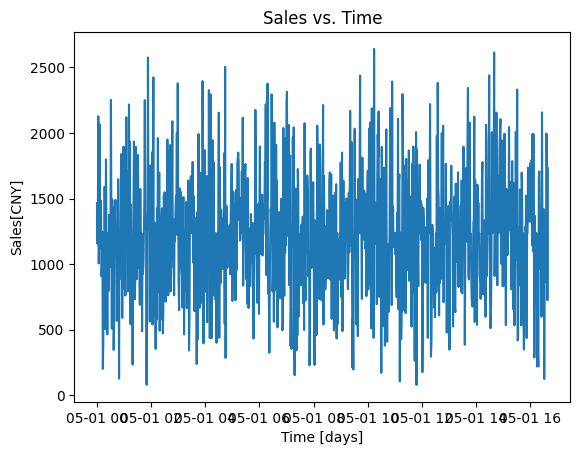

In [22]:
# plot sales timeseries
plt.plot(timestamps, sales)
plt.title("Sales vs. Time")
plt.xlabel("Time [days]")
plt.ylabel("Sales[CNY]")

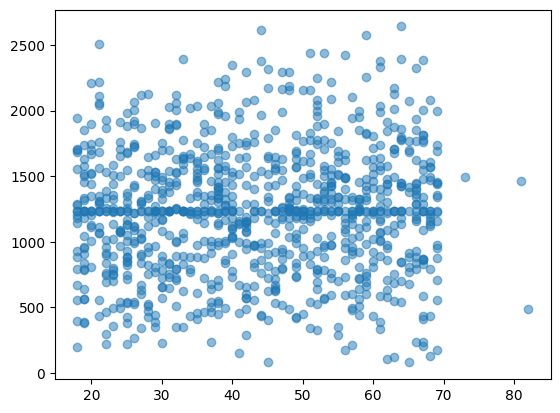

In [23]:
# 可视化用户年龄与销售额的关系      
plt.scatter(ages, sales, alpha=0.5) 

{'whiskers': [<matplotlib.lines.Line2D at 0x21f201560d0>,
 'caps': [<matplotlib.lines.Line2D at 0x21f247de450>,
 'boxes': [<matplotlib.lines.Line2D at 0x21f24508a10>],
 'medians': [<matplotlib.lines.Line2D at 0x21f247df790>],
 'fliers': [<matplotlib.lines.Line2D at 0x21f247e8110>],
 'means': []}

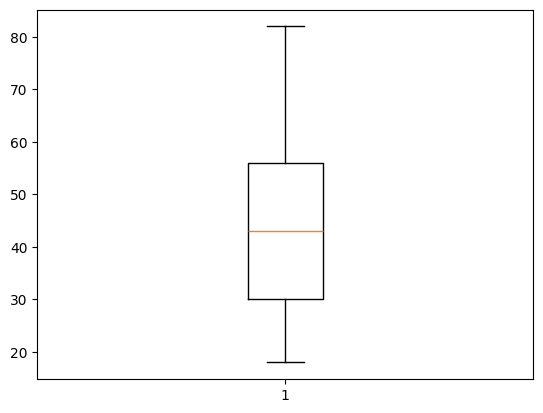

In [24]:
# ages
plt.boxplot(ages)

Text(0, 0.5, 'Distribution Density')

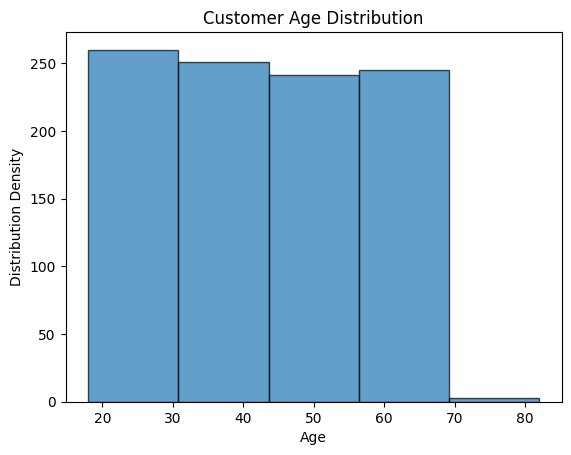

In [28]:
# histogram for ages
plt.hist(ages, bins=5, edgecolor='black', alpha=0.7)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Distribution Density")

Text(0.5, 1.0, 'Sales Distribution by Region')

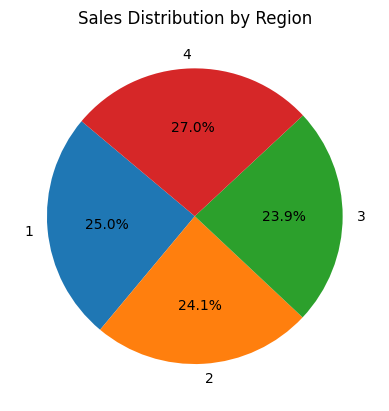

In [32]:
# 区域销售占比图 - 饼图
plt.pie(region_sales, labels=unique_regions, autopct='%1.1f%%', startangle=140)
plt.title("Sales Distribution by Region")

## 4. 模型评估 Model Evaluation <a id="4"></a> 

## 5. 业务理解/知识深化和提升  <a id="5"></a> 

总结：
项目目标: 通过一个实际案例将NumPy的基础操作、数据预处理、分析和可视化结合起来。

练习步骤：
1. 初步了解案例的数据类型。学习如何用NumPy生成合成数据， 了解可能会有“数据修改”挖的坑。 
   → NumPy函数np.random.randn、np.random.randint， seed等。
2. 练习了对原始数据的探讨和体检, 创建了第一个自己的函数
3. 预处理部分需要处理缺失值和异常值。
   → 对于缺失值，可以用均值，中值填充，
   → NumPy的np.isnan和np.nanmean等函数来处理。异常值则可以用标准差方法和IQR方法检测和替换，使用布尔索引和np.where函数。
4. 数据分析和建模： 计算基本的统计指标，比如总销售额、平均年龄、地区销售分布等，展示NumPy的聚合函数如sum、mean、unique等。创建了第一个自己的分析模型。
5. 可视化部分使用Matplotlib绘制折线图、直方图和饼图，展示销售额趋势、用户年龄分布和地区销售占比。

学习体会和反馈？？